In [62]:
# Relevant python functions
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import sys
import matplotlib.pyplot as plt
import folium
from collections import Counter
import matplotlib.patches as mpatches
import contextily as ctx
from matplotlib.ticker import ScalarFormatter, MaxNLocator
from shapely.geometry import box
import matplotlib.lines as mlines


# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)
import functions_local as inv_local 
import functions_national as inv_natl
import functions_inference as infr

In [63]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]


In [64]:
# Target Directory 
directory = './Inventory_Outputs/Synthesized_Local/'

# Make directory and intermediate directory
os.makedirs(directory, exist_ok=True)
dir_attribution = directory + 'FootprintAttribution/'
dir_intermediate = dir_attribution + 'Intermediate/'
os.makedirs(dir_intermediate, exist_ok=True)

# Figure Directory 
fig_dir = './Figures/General/'
os.makedirs(fig_dir, exist_ok=True)

## PREPROCESS PARCEL DATA

In [65]:
# Load parcel data and Census blocks 
parcels = gpd.read_file('./Input_Data/Local/Hayward_Parcels.geojson')
parcels = parcels.to_crs(epsg=crs_main)
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2010/Hayward_blocks.geojson')

# Load extended parcel data from Hayward GIS 
extended_data = pd.read_csv('./Input_Data/Local/Additional_Parcel_Information.csv', low_memory=False)

### **Clean data**

In [66]:
# Remove unreasonable values 

# Remove extremely old points (one point has eff year built of 1062 - seem like typos of "1062" instead of "1962")
drop_idx = extended_data[(extended_data['Eff_Year_Built']<1700) | (extended_data['Eff_Year_Built']>2026)].index
print(len(drop_idx))
extended_data.loc[drop_idx, 'Eff_Year_Built'] = np.nan
drop_idx = extended_data[(extended_data['Year_Built']<1700) | (extended_data['Year_Built']>2026)].index
print(len(drop_idx))
extended_data.loc[drop_idx, 'Year_Built'] = np.nan

# Remove cases in tax data where number of stories is listed as 0
extended_data.loc[extended_data[extended_data['Num_Stories'] == 0].index, 'Num_Stories'] = np.nan

# Correct tax data type of 1.4 stories
extended_data.loc[extended_data[extended_data['Num_Stories'] == 1.4].index, 'Num_Stories'] = 1.5


3
0


In [67]:
# Drop columns that will not be used 
parcels = parcels.drop(columns=['APN_ACA', 'OBJECTID', 'APN_GIS', 'APN_BK_PG',
                                'OWNERCENSORED', 'P_HouseNum', 'P_Prefix', 'P_Pre_Type',
                                'P_Street_Name', 'P_Street_Type', 'P_Suffix_Dir', 'P_House_Unit',
                                'P_City', 'P_State', 'P_Zipcode', 'P_AREA', 'P_ST_ADDRESS',
                                'M_ST_ADDRESS', 'M_CITY', 'M_STATE', 'M_ZIP_FULL', 'TAXRATEAREA'])

### **Map to a common ontology**

In [68]:
# Define map between Parcel Use Description and NSI 
# NOTE: _VAC indicates that the parcel is labeled as "planned" or "vacant"
use_map = {
    np.nan : None,
    'Townhouse - Planned Development, Common Area or use' : 'RES3_VAC', 
    'Assisted Living Apartments' : 'RES6', 
    'Vacant industrial land (may include misc. imps)' : 'IND_VAC',
    'Triplex; double or duplex with single family home' : 'RES3B', 
    'Condominium - townhouse, first sale' : 'RES3',
    'SFR - Planned Development Tract, Common Area or use' : 'RES1_VAC', 
    '3 units, lesser quality than 2300 or unknown legal' : 'RES3B',
    'Condominium - townhouse, common area' : 'RES3', 
    'Commercial repair garage' : 'COM3', 
    'Lodgehall and/or clubhouse' : 'COM8', 
    'Bank' : 'COM5', 
    'Residential property converted to 5 or more units' : 'RES3', 
    'Wrecking yards' : 'NOTBLDG',
    'Vacant apartment common area or use' : 'RES3_VAC',
    'Condominium - single residential living unit' : 'RES3',
    'National Chain Retailer' : 'COM1',
    'None' : None, 
    'Single Family Res - Duet Style, R&T 402.1' : 'RES3A', 
    'Parking garage' : 'COM3', # NAICS 812930 (Parking Lots and Garages) classified as COM3 using Hazus document 
    'Single family residential homes used as such' : 'RES1', 
    'Five or more single family res homes' : 'RES1', 
    'Five or more single family res home': 'RES1',
    'Other recreational activity, e.g. rinks, stadiums' : 'COM8', 
    'Single family residential home, R&T 402.1' : 'RES1', 
    'Nursing/Custodial Care Facility' : 'RES6', 
    'Four living units; e.g. fourplex or triplex w/SFR' : 'RES3B', 
    '2 units, SFR with detattched accessory dwelling unit' : 'RES3A',
    'Single-tenant Retail Store' : 'COM1', 
    'Condominium Common Area or use' : 'RES3', 
    'Townhouse - Planned Development, R&T 402.1' : 'RES3_VAC',
    'Four residential living units, R&T 402.1' : 'RES3B', 
    'Multiple-Res building of 5 or more units + commercial units' : 'RES3M', # Indicating mixed use
    'Exempt Public Agency' : 'GOV1', 
    'Condominium - townhouse, common area' : 'RES3', 
    'Two, three or four single family homes' : 'RES1', 
    'Single family res home with non-economic 2nd unit' : 'RES3A',
    'Restricted residential income property' : 'RES3',
    'Res property of 2,3 or 4 units with rooming house' : 'RES3B',
    'SFR - Planned Development Tract with Common Area' : 'RES1_VAC', 
    'Mobile home park parcel with improvements' : 'RES2', 
    'SFR - Planned Development Tract, R&T 402.1' : 'RES1_VAC',
    'One to five story office building' : 'COM4', 
    'Improved rural-residential homesite.' : 'RES1',
    'Condominium - Townhouse R&T 402.1' : 'RES3',
    'Condominium-industrial, common area or use' : 'IND', # Insufficient specificity for more detailed designation 
    'Vacant apartment land, capable of 5 or more units' : 'RES3_VAC', 
    'Store/Office with Apts/Lofts' : 'RES3M', # Indicating mixed use
    'Condominium - single res unit, R&T 402.1': 'RES3',
    'Multi-Res building of 5 or more units R&T 402.1 + commercial': 'RES3M', # Indicating mixed use
    '2 units, SFR with attached accessory dwelling unit' : 'RES3A',
    '2 units, SFR with attached accessory dwelling unit, R&T 402.1' : 'RES3A', 
    'Single Family Res - Duet Style' : 'RES3A', 
    'Medical-Residential Care Facility (SFR/Res Imps)' : 'RES6', 
    'Church' : 'REL1', 
    'Single Family Res home with slight commercial/ind' : 'RES1', 
    'Vacant residential tract lot' : 'RES_VAC', 
    'Rural property in transition to a higher use' : 'UNK',
    'Single family modular built off site' : 'RES2', 
    'SFR with junior accessory dwelling unit' : 'RES3A', 
    'Vacant rural-res homesites, may incl misc. imps' : 'RES_VAC',  
    'Miscellaneous improved commercial' : 'COM', # Insufficient specificity for more detailed designation 
    'Duet/Duplex/Triplex - Planned Development Tract w/Common Area' : 'RES3B_VAC', 
    'Condominium-industrial' : 'IND', # Insufficient specificity for more detailed designation 
    'SFR Detached Site Condominium , Common Area or use' : 'RES1', 
    'More than 1 mobile home, or M/H w/other res units' : 'RES2', 
    'Double or duplex type - two units' : 'RES3A', 
    'Historical commercial' : 'COM1', 
    'Multiple residential building of 5 or more units.' : 'RES3',
    'Vacant residential land, zoned 4 units or less' : 'RES3B_VAC',
    'Condominium - townhouse style' : 'RES3', 
    'Fraternities and sororities' : 'RES5', # No explicit NAICS for frats, so classified here as dorms 
    'Residential Imps on Industrial Land' : 'RES_VAC', 
    '4 units, lesser quality than 2400 or unknown legal' : 'RES3B',
    'Rural property used for agriculture, 10+ acres' : 'AGR1', 
    'SFR - Manufactured Home (MH on permanent foundation)' : 'RES2', 
    'Service Stations' : 'COM1', # NAICS 447110 checked using Hazus document
    'Warehouse' : 'COM2', # NAICS 493110 (General Warehousing and Storage) checked using Hazus document 
    'Non-Condo Live/Work' : 'RES3M',  
    '2 units, lesser quality than 2200 or unknown legal' : 'RES3B',
    '2 units, SFR with detached accessory dwelling unit, R&T 402.1' : 'RES3A', 
    '\t2 units, SFR with detached accessory dwelling unit, R&T 402.1' : 'RES3A', 
    'SFR Detached Site Condominium' : 'RES1', 
    'Townhouse - Planned Development' : 'RES3_VAC', 
    '\tCondominium - single residential living unit': 'RES3', 
    '\tCondominium - townhouse, common area' : 'RES3', 
    'Vacant commercial land (may include misc. imps)' : 'COM_VAC',
    'Single family residential (tract) common area or use' : 'RES1',
    'Golf course' : 'NOTBLDG', # DIVERGE: NAICS 713910 (Golf Courses and Country Clubs) classified as COM8. I chose to leave as 'NOTBLDG' in this case 
    'Automobile dealership' : 'COM1', # NAICS 441110 checkecd against Hazus
    'Bank' : 'COM5',
    'Bowling alley' : 'COM8',
    'Car wash' : 'NOTBLDG', #### DIVERGE: NAICS 811192 (Car Washes) classified as COM3. I chose to leave this as 'NOTBLDG' in this case 
    'Cemetery' : 'NOTBLDG', #### DIVERGE: NAICS 812220 (Cemetaries and Crematories) classified as COM4. I chose to leave this as 'NOTBLDG' in this case 
    'Church' : 'REL1',
    'Commercial Imps on Residential Land' : 'RES3M',
    'Condominium - urban res unit above, common area or use' : 'RES3M', 
    'Condominium-commercial retail' : 'COM1', 
    'Condominium-commercial retail, common area or use' : 'COM1',
    'Condominium-office' : 'COM4',
    'Cooperatives (divided)' : 'RES3', # There could be housing or business cooperatives, but assuming here it is a housing cooperative
    'Data Center' : 'IND5',
    'Exempt Public Agency' : 'GOV1',
    'Fitness Center/Health Club/Gym' : 'COM8',
    'Funeral home' : 'COM3', # NAICS 812210 chekced using Hazus document  
    'Heavy industrial' : 'IND1',
    'Historical commercial' : 'COM1',
    'Hospital (general)' : 'COM6',
    'Industrial Flex/R&D' : 'IND2',
    'Industrial Light/Manufacturing' : 'IND2',
    'Lodgehall and/or clubhouse'  : 'COM8',
    'Medical - Dental building'  : 'COM7',
    'Misc. industrial (improved); no other ind code'  : 'IND', # Insufficient specificity for more detailed designation 
    'Miscellaneous improved commercial' : 'COM1',
    'Motel' : 'RES4',
    'National Chain Retailer' : 'COM1',
    'Non-Condo Live/Work' : 'RES3M',
    'Nursing/Custodial Care Facility' : 'RES6',
    'One to five story office building' : 'COM4',
    'Other institutional property' : 'GOV1', # Commonly used for community or public servies purposes, so assumed GOV1 was most appropriate 
    'Other recreational activity, e.g. rinks, stadiums' : 'COM8',
    'Over five story office building' : 'COM4',
    'Parking lot' : 'NOTBLDG',
    'Property leased to a public utility' : 'GOV1',
    'Property owned by a public utility' : 'GOV1',
    'Res property of 2,3 or 4 units with rooming house' : 'RES3',
    'Residential Imps on Commercial Land' : 'RES3M', 
    'Residential Imps on Industrial Land' : 'RES3M',
    'Restaurant - Fast Food' : 'COM8', # NAICS 722513 checked against Hazus document 
    'Restaurant - small or in-line walk-in restaurant / cafe' : 'COM8', # NAICS 722513 checked against Hazus document 
    'Restricted residential income property' : 'RES3', 
    'Rural property in transition to a higher use' : 'NOTBLDG',
    'Rural property used for agriculture, 10+ acres' : 'NOTBLDG',
    'School' : 'EDU1',
    'Shopping Center-NBHD without anchor (strip mall)' : 'COM1',
    'Shopping Center-NBHD/Grocery or Retail anchor' : 'COM1',
    'Shopping Center-Regional Mall' : 'COM1',
    'Single-tenant Retail Store' : 'COM1',
    'Skilled Nursing Facility' : 'COM7',
    'Store/Office with Apts/Lofts' : 'RES3M',
    'Supermarket' : 'COM1',
    'Terminals, trucking and distribution' : 'COM2', # NAICS 484110 (General Freight Trucking, Local) and 484121 (General Freight Trucking, Long-Distance) checked using Hazus document 
    'Vacant apartment land, R&T 402.1' : 'RES3_VAC',
    'Vacant apartment land, capable of 5 or more units' : 'RES3_VAC',
    'Vacant commercial land (may include misc. imps)' : 'COM_VAC',
    'Vacant residential land, zoned 4 units or less' : 'RES3_VAC',
    'Vacant residential tract lot' : 'RES3_VAC',
    'Vacant rural land, not usable even for agriculture' : 'NOTBLDG',
    'Rural property with significant commercial use':'COM',
    'Veterinarian Office' : 'COM1',
    'Warehouse-Cold Storage' : 'COM2', # NAICS 493120 checked against Hazus docuemnt 
    'Warehouse-Self Storage' : 'COM4', # NAICS 531130 chekced against Hazus document 
}


### CONVERT PARCEL USE DESCRIPTION TO NSI ###
extended_data['Use_Description_Hazus'] = extended_data['Use_Description'].apply(inv_local.map_values, occ_map=use_map)


### **Link parcel geometry to extended data**

In [73]:
# Ensure unique APN_PQs in parcel data by dissolving geometries for matching APN_PQ
print(len(parcels))
duplicates = parcels[parcels.duplicated(subset=['APN_PQ'])]
dissolved = duplicates.dissolve(by='APN_PQ', as_index=False)
gdf_cleaned = parcels.drop_duplicates(subset='APN_PQ', keep='first')
gdf_cleaned = gdf_cleaned.set_index('APN_PQ')
dissolved = dissolved.set_index('APN_PQ')
gdf_cleaned.update(dissolved)
parcels_clean = gdf_cleaned.reset_index()
print(len(parcels_clean))

# Clean extended parcel data by removing duplicates - some parcels appear in twice in the databse, so keep more recent entry (last)
# Drop cases with no data
extended_data = extended_data.drop_duplicates()
extended_data = extended_data.drop_duplicates(subset=['APN_PQ'], keep='last')
extended_data = extended_data[extended_data['Use_Description_Hazus'].notna()]

# Merge extended parcel data with parcel geometries -- effectively imposing boundaries becuase extended_data only available for Hayward boundaries
parcels_ext = parcels_clean.merge(extended_data, on='APN_PQ', how='right')
len(parcels_ext)

# Drop cases 

68373
67907


37282

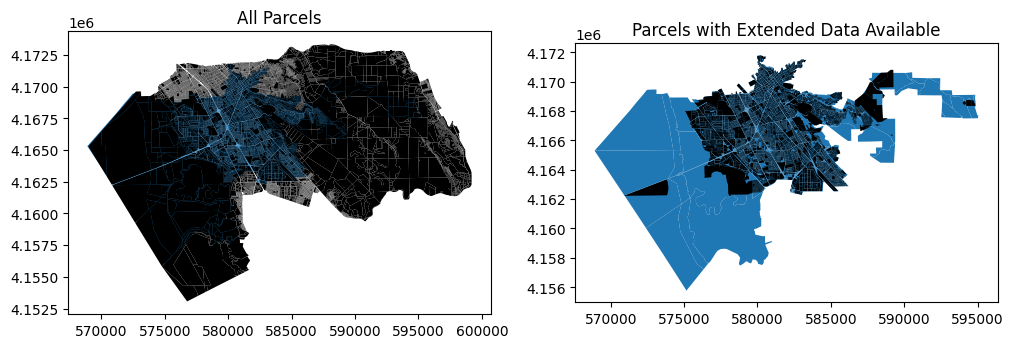

JSON File Saved


In [74]:
#  Plot
fig, ax = plt.subplots(1,2, figsize = (12, 12))
hayward_blocks.plot(ax=ax[0])
parcels.plot(ax=ax[0], color ='black', markersize = 0.1)
ax[0].set_title('All Parcels')
hayward_blocks.plot(ax=ax[1])
parcels_ext.plot(ax=ax[1], color ='black', markersize = 0.1)
ax[1].set_title('Parcels with Extended Data Available')
plt.show()

# Save parcels that have extended parcel data available 
inv_local.gdf_to_json(parcels_ext.copy(), dir_intermediate + 'Extended_Data_Parcels.json')

In [75]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS
# m = folium.Map(location=[parcels.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, parcels.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)


# # Create a base map
# # Add footprints (polygons)
# folium.GeoJson(hayward_blocks.copy().to_crs(crs_plot), color = 'gray').add_to(m)
# folium.GeoJson(parcels_ext.copy().to_crs(crs_plot), color = 'blue').add_to(m)

# display(m)

## **Tag footprints with possible parcels**

In [76]:
# Load parcel data 
parcels_clean = inv_local.json_to_gdf(dir_intermediate + 'Extended_Data_Parcels.json', crs_main)

# Load preprocessed footprint data 
footprints = inv_local.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)


In [77]:
### ASSIGN FOOTPRINTS TO PARCELS ###

# Perform spatial join to add APN_PQ from parcels_clean to footprints
footprints_with_apn = gpd.sjoin(footprints, parcels_clean[['APN_PQ', 'geometry']], how="left", predicate="intersects")
inv_local.gdf_to_json(footprints_with_apn, dir_intermediate + 'Footprints_with_Parcels_Unfiltered.json')

# Merge the parcel geometry to the footprints based on the spatial join
parcels_clean = parcels_clean.rename(columns={'geometry': 'parcel_geometry'})
footprints_with_apn = footprints_with_apn.merge(parcels_clean[['APN_PQ', 'parcel_geometry']], on='APN_PQ')

### DROP FOOTPRINT ASSOCIATION WITH SOME PARCELS BASED ON PERCENTAGE WITHIN EACH ###

# Calculate the area of each footprint
footprints_with_apn['footprint_area'] = footprints_with_apn.geometry.area

# Calculate the intersection area between the footprint and parcel geometries
footprints_with_apn['intersection'] = footprints_with_apn.geometry.intersection(footprints_with_apn['parcel_geometry'])
footprints_with_apn['intersection_area'] = footprints_with_apn['intersection'].area

# Calculate the percentage of the footprint that is within the parcel
footprints_with_apn['percent_overlap'] = (footprints_with_apn['intersection_area'] / footprints_with_apn['footprint_area']) * 100

# First, filter out rows where the overlap is less than a given % of the footprint wiht a given parcel 
# print(len(footprints_with_apn))
# footprints_with_apn_filter = footprints_with_apn[footprints_with_apn['percent_overlap'] >= 5]
# NOTE: in the case of Hayward, decided not to include this filter based on spot checking data 
footprints_with_apn_filter = footprints_with_apn

# Second, filter rows that have at least a given % of the footprint within a single parcel (drop other parcels associated with that house)
print(len(footprints_with_apn_filter))
ftpt_above = footprints_with_apn_filter[footprints_with_apn_filter['percent_overlap'] >= 95]
ftpt_ids_above = list(ftpt_above['FootprintID'].unique())
ftpt_below = footprints_with_apn_filter[footprints_with_apn_filter['percent_overlap'] < 95]
ftpt_below_reduced = ftpt_below[~ftpt_below['FootprintID'].isin(ftpt_ids_above)]

# Recombine dataframes 
footprints_filtered = pd.concat([ftpt_above, ftpt_below_reduced], axis=0, ignore_index=True)
print(len(footprints_filtered))

# Reset geometry and drop columns 
footprints_filtered = footprints_filtered.drop(columns=['intersection', 'footprint_area', 'intersection_area', 'percent_overlap', 'index_right','parcel_geometry'])
footprints_filtered.set_geometry('geometry', inplace=True)

# Remove duplicate rows 
print('With Duplicates:', len(footprints_filtered))
footprints_filtered = footprints_filtered.drop_duplicates(keep = 'first')
print('Without Duplicates:', len(footprints_filtered))

# Save data
inv_local.gdf_to_json(footprints_filtered, dir_intermediate + 'Footprints_with_Parcels_Filtered.json')


JSON File Saved
57227
50061
With Duplicates: 50061
Without Duplicates: 50061
JSON File Saved


## **Update footprints to only include those with address data**

In [78]:
# Load preprocessed footprint data 
footprints = inv_local.json_to_gdf(dir_intermediate + 'Footprints_with_Parcels_Filtered.json', crs_main)

# Load address point data (attributed to footprints) 
points = inv_natl.json_to_gdf(dir_intermediate + '/Address_Points_Attributed.json', crs_main)

# Filter for footprints that do/do not contain address points 
footprints_with_addresses = footprints[footprints['FootprintID'].isin(points['POINT_FootprintID'].to_list())]
footprints_no_addresses = footprints[~footprints['FootprintID'].isin(points['POINT_FootprintID'].to_list())]
print(len(footprints))
print(len(footprints_with_addresses))
print(len(footprints_no_addresses))


50061
44748
5313


In [79]:
## TODO: MTL something with ADUs? 
# len(points[(points['FC_Hazus']=='RES1_ADU') & (points['POINT_DropFlag']==0)])

In [80]:
# ## Plot footprinst with no addresses

# 

# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS
# m = folium.Map(location=[parcels.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, parcels.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Create a base map
# # Add footprints (polygons)
# folium.GeoJson(footprints_with_addresses.copy().to_crs(crs_plot), color = 'gray').add_to(m)
# folium.GeoJson(footprints_no_addresses.copy().to_crs(crs_plot), color = 'red').add_to(m)
# folium.GeoJson(parcels[parcels['Use_Description_Hazus'].isin(['RES4','RES5','RES6'])].copy().to_crs(crs_plot), color = 'blue').add_to(m)

# display(m)


## **Attribute Parcel Data to Footprints**

In [81]:
# Load parcel-level tax data and parcels 
parcels = inv_local.json_to_gdf(dir_intermediate + 'Extended_Data_Parcels.json', crs_main)

# Load point-based address data
address_points = inv_local.json_to_gdf(dir_intermediate + 'Address_Points_Attributed.json', crs_main)

# For the purposes of the data merge, only use address points with APN_PQs that have been scraped 
# There are 5 residential APN_PQs that were not scraped because they did not have property reports available 
print(len(address_points))
address_points = address_points[address_points['APN_PQ'].isin(list(extended_data['APN_PQ'].unique()))]
print(len(address_points))

# # Create new columns to be used in merge 
# address_points['FC_Updated'] = None
# address_points['AddressID_Updated'] = None
# address_merge['Num_Points'] = 1
# address_merge['FootprintID']=np.nan

# # Cast all columns as type object (general-purpose data type in pandas that can hold any python object)
# for col in address_merge.columns:
#     address_merge[col] = address_merge[col].astype(object)

62320
60306


In [61]:
parcels[parcels['Use_Description_Hazus'].isna()].columns

Index(['geometry', 'APN_PQ', 'Use_Description', 'Use_Code', 'Landslide',
       'Liquefaction', 'Fault_Zone', 'Total_Value', 'Improvement_Value',
       'Homeowner_Exemption', 'Year_Built', 'Eff_Year_Built', 'Bldg_Class',
       'Construction', 'Bldg_Condition', 'Bldg_Quality', 'Bldg_Area',
       'Num_Bldg', 'Num_Units', 'Num_Stories', 'Parking',
       'Use_Description_Hazus'],
      dtype='object')

In [128]:
parcels.columns

Index(['geometry', 'APN_PQ', 'Use_Description', 'Use_Code', 'Landslide',
       'Liquefaction', 'Fault_Zone', 'Total_Value', 'Improvement_Value',
       'Homeowner_Exemption', 'Year_Built', 'Eff_Year_Built', 'Bldg_Class',
       'Construction', 'Bldg_Condition', 'Bldg_Quality', 'Bldg_Area',
       'Num_Bldg', 'Num_Units', 'Num_Stories', 'Parking',
       'Use_Description_Hazus'],
      dtype='object')

In [ ]:
### MERGE ADDRESS POINTS WITH SCRAPED DATA ###

# Flag to determine if scaling is based on footprint area or building volumne 
use_height = True
new_ftpts_with_parcel = {}

counter = 0 
counter1 = 0 
ftpt_unique_index = 0

# Loop through parcels to populate dataframe 
print(len(parcels), 'parcels total (looping through these now)')
for index, row in parcels.iterrows():

    counter1 += 1
    if counter1 % 2000 == 0:
        print(counter1)

    ## RESIDENTIAL PARCEL 

    if 'RES' in row['Use_Description_Hazus']:

        # Get footprints within parcel 
        parcel_ftpt_address = footprints_with_addresses[footprints_with_addresses['APN_PQ']==row['APN_PQ']]
        parcel_ftpt_no_address = footprints_no_addresses[footprints_no_addresses['APN_PQ']==row['APN_PQ']]

        # ONE FOOTPRINT WITH ADDRESS DATA
        if len(parcel_ftpt_address) == 1: 
             pass

            # # Associate all parcel data with given footprint 
            # row['FootprintID'] = int(parcel_ftpt_address['FootprintID'].values[0])
            # new_ftpts_with_parcel[ftpt_unique_index] = row
            # ftpt_unique_index += 1
        
        # MULTIPLE FOOTPRINTS WITH ADDRESS DATA 
        elif len(parcel_ftpt_address) > 1:
             
             # Associate all parcel data with set of footprints 

            # Set all relevant footprint IDs to have parcel data associated with them
            for index, ftpt in parcel_ftpt_address.iterrows():
                cur_row = row.copy()
                cur_row['FootprintID'] = int(ftpt['FootprintID'])
                

                # Adjust scaling on various rows when splitting data across footprints
                if use_height: 
                    num = ftpt['FootprintArea'] * ftpt['FootprintHeight'] # Volumne of each building
                    denom = sum(parcel_ftpt_address['FootprintArea'] * parcel_ftpt_address['FootprintHeight']) # Summed volumne of everything in parcel
                    factor = num / denom 
                else: 
                    factor = ftpt['FootprintArea'] / sum(parcel_ftpt_address['FootprintArea'])

                # Assign scaling for area and value 
                cur_row['Total_Value'] = cur_row['Total_Value'] * factor
                cur_row['Improvement_Value'] = cur_row['Improvement_Value'] * factor
                cur_row['Bldg_Area'] = cur_row['Bldg_Area'] * factor

                # Assign number of units - allow for 0 if original scrape has 0, but round to 1 in all other 0 cases 
                if cur_row['Num_Units'] > 0: 
                    cur_row['Num_Units'] = max(np.round(cur_row['Num_Units'] * factor),1)

                # Assign number of buildings - allow for 0 if original scrape has 0, but round to 1 in all other 0 cases 
                if cur_row['Num_Bldg'] > 0: 
                    cur_row['Num_Bldg'] = max(np.round(cur_row['Num_Bldg'] * factor),1)

                # Assign data to footprint 
                new_ftpts_with_parcel[ftpt_unique_index] = cur_row.copy()
                ftpt_unique_index += 1


                print(factor)
    



                # # Adjust scaling on various rows when splitting data across footprints
                # if use_height: 
                #     num = address_with_ftpt.loc[gdf_index,'FootprintArea'] * address_with_ftpt.loc[gdf_index,'FootprintHeight'] # Volumne of each buildint
                #     denom = sum(address_with_ftpt.loc[gdf_index,'FootprintArea'] * address_with_ftpt.loc[gdf_index,'FootprintHeight']) # Summed volumne of everything in parcel
                #     factor = num / denom 
                # else: 
                #     factor = address_with_ftpt.loc[gdf_index,'FootprintArea'] / sum(address_with_ftpt.loc[gdf_index,'FootprintArea'])
                # address_merge.loc[gdf_index, 'Scrape_Total_Value_Update'] = row['Total_Value'] * factor
                # address_merge.loc[gdf_index, 'Scrape_Improvement_Value_Update'] = row['Improvement_Value'] * factor
                # address_merge.loc[gdf_index, 'Scrape_Bldg_Area_Update'] = row['Bldg_Area'] * factor

                # # Assign number of units - allow for 0 if original scrape has 0, but round to 1 in all other 0 cases 
                # if row['Num_Units']== 0: 
                #     address_merge.loc[gdf_index, 'Scrape_Num_Units_Update'] = 0
                # else: 
                #     address_merge.loc[gdf_index, 'Scrape_Num_Units_Update'] = (np.round(row['Num_Units'] * factor)).apply(lambda val: max(val, 1))

                # # Assign number of buildings - allow for 0 if original scrape has 0, but round to 1 in all other 0 cases 
                # if row['Num_Bldg']== 0: 
                #     address_merge.loc[gdf_index, 'Scrape_Num_Bldg_Update'] = 0
                # else: 
                #     address_merge.loc[gdf_index, 'Scrape_Num_Bldg_Update'] = (np.round(row['Num_Bldg'] * factor)).apply(lambda val: max(val, 1))

                # # Record infomration for tracking 
                # address_merge.loc[gdf_index, 'DataUpdate'] = 'Split Parcel Data Between Footprints'
                # address_merge.loc[gdf_index, 'Num_Addresses_Split'] = len(gdf_index)

                
            


    



            raise ValueError

        #     # counter += 1
        
        # # MULTIPLE FOOTPRINTS WITH ADDRESS DATA 
        # elif len(parcel_ftpt_address) > 1:

        #     # Set all relevant footprint IDs to have parcel data associated with them
        #     i = 0 
        #     for ftpt_id in parcel_ftpt_address['FootprintID'].values:
        #         ftpt_id = int(parcel_ftpt_address['FootprintID'].values[i])
        #         new_ftpts_with_parcel[ftpt_id] = row
 
        #     new_ftpts_with_parcel[ftpt_ids] = row
        #     counter += 1







        #     ftpt_unique_index += 1 



            # # Associate data with each footprint 
            # address_merge = associate_scraped_data(address_merge, gdf_index, row, columns)

            # # Adjust scaling on various rows when splitting data across footprints
            # if use_height: 
            #     num = address_with_ftpt.loc[gdf_index,'FootprintArea'] * address_with_ftpt.loc[gdf_index,'FootprintHeight'] # Volumne of each buildint
            #     denom = sum(address_with_ftpt.loc[gdf_index,'FootprintArea'] * address_with_ftpt.loc[gdf_index,'FootprintHeight']) # Summed volumne of everything in parcel
            #     factor = num / denom 
            # else: 
            #     factor = address_with_ftpt.loc[gdf_index,'FootprintArea'] / sum(address_with_ftpt.loc[gdf_index,'FootprintArea'])
            # address_merge.loc[gdf_index, 'Scrape_Total_Value_Update'] = row['Total_Value'] * factor
            # address_merge.loc[gdf_index, 'Scrape_Improvement_Value_Update'] = row['Improvement_Value'] * factor
            # address_merge.loc[gdf_index, 'Scrape_Bldg_Area_Update'] = row['Bldg_Area'] * factor

            # # Assign number of units - allow for 0 if original scrape has 0, but round to 1 in all other 0 cases 
            # if row['Num_Units']== 0: 
            #     address_merge.loc[gdf_index, 'Scrape_Num_Units_Update'] = 0
            # else: 
            #     address_merge.loc[gdf_index, 'Scrape_Num_Units_Update'] = (np.round(row['Num_Units'] * factor)).apply(lambda val: max(val, 1))

            # # Assign number of buildings - allow for 0 if original scrape has 0, but round to 1 in all other 0 cases 
            # if row['Num_Bldg']== 0: 
            #     address_merge.loc[gdf_index, 'Scrape_Num_Bldg_Update'] = 0
            # else: 
            #     address_merge.loc[gdf_index, 'Scrape_Num_Bldg_Update'] = (np.round(row['Num_Bldg'] * factor)).apply(lambda val: max(val, 1))

            # # Record infomration for tracking 
            # address_merge.loc[gdf_index, 'DataUpdate'] = 'Split Parcel Data Between Footprints'
            # address_merge.loc[gdf_index, 'Num_Addresses_Split'] = len(gdf_index)


            raise ValueError



            # address_merge = inv_local.associate_scraped_data(address_merge.copy(), gdf_index, row, scraped_merge.columns)
            

        # # NO FOOTPRINTS, ONE OR MORE ADDRESS POINT(S)
        # if len(parcel_ftpt_address) == 0 and len(parcel_ftpt_no_address) == 0: 
        #     pass

        # # TODO 

        # elif len()

# print(counter / counter1)


    # raise ValueError


37282 parcels total (looping through these now)
0.6972234211890701
0.30277657881092984


ValueError: 

In [126]:
row

geometry                 POLYGON ((582985.8342421023 4166131.0933445133...
APN_PQ                                                     452-0080-013-00
Use_Description               Single family residential homes used as such
Use_Code                                                            1100.0
Landslide                                                               No
Liquefaction                                                            No
Fault_Zone                                                              No
Total_Value                                                       994500.0
Improvement_Value                                                 637500.0
Homeowner_Exemption                                                    0.0
Year_Built                                                          1946.0
Eff_Year_Built                                                      1946.0
Bldg_Class                                                            D45A
Construction             

In [119]:
ftpt

(8641,
 geometry           POLYGON Z ((582945.647541114 4166111.129264606...
 FootprintArea                                            2011.332088
 FootprintHeight                                            10.214286
 CensusBlock                                          060014379002006
 CensusTract                                              06001437900
 FootprintID                                                    10164
 APN_PQ                                               452-0080-013-00
 Name: 8641, dtype: object)

In [121]:
parcel_ftpt_address

,geometry,FootprintArea,FootprintHeight,CensusBlock,CensusTract,FootprintID,APN_PQ
8641,"POLYGON Z ((582945.648 4166111.129 0, 582947.1...",2011.332088,10.214286,060014379002006,06001437900,10164,452-0080-013-00
8642,"POLYGON Z ((582962.897 4166117.247 0, 582968.8...",926.918084,9.625000,060014379002006,06001437900,10165,452-0080-013-00


In [116]:
ftpt

(8641,
 geometry           POLYGON Z ((582945.647541114 4166111.129264606...
 FootprintArea                                            2011.332088
 FootprintHeight                                            10.214286
 CensusBlock                                          060014379002006
 CensusTract                                              06001437900
 FootprintID                                                    10164
 APN_PQ                                               452-0080-013-00
 Name: 8641, dtype: object)

In [132]:
new_ftpts_with_parcel[0]

geometry                 POLYGON ((582985.8342421023 4166131.0933445133...
APN_PQ                                                     452-0080-013-00
Use_Description               Single family residential homes used as such
Use_Code                                                            1100.0
Landslide                                                               No
Liquefaction                                                            No
Fault_Zone                                                              No
Total_Value                                                  693388.692373
Improvement_Value                                            444479.931008
Homeowner_Exemption                                                    0.0
Year_Built                                                          1946.0
Eff_Year_Built                                                      1946.0
Bldg_Class                                                            D45A
Construction             

In [133]:
new_ftpts_with_parcel[1]

geometry                 POLYGON ((582985.8342421023 4166131.0933445133...
APN_PQ                                                     452-0080-013-00
Use_Description               Single family residential homes used as such
Use_Code                                                            1100.0
Landslide                                                               No
Liquefaction                                                            No
Fault_Zone                                                              No
Total_Value                                                  301111.307627
Improvement_Value                                            193020.068992
Homeowner_Exemption                                                    0.0
Year_Built                                                          1946.0
Eff_Year_Built                                                      1946.0
Bldg_Class                                                            D45A
Construction             

In [134]:
row

geometry                 POLYGON ((582985.8342421023 4166131.0933445133...
APN_PQ                                                     452-0080-013-00
Use_Description               Single family residential homes used as such
Use_Code                                                            1100.0
Landslide                                                               No
Liquefaction                                                            No
Fault_Zone                                                              No
Total_Value                                                       994500.0
Improvement_Value                                                 637500.0
Homeowner_Exemption                                                    0.0
Year_Built                                                          1946.0
Eff_Year_Built                                                      1946.0
Bldg_Class                                                            D45A
Construction             

In [101]:
new_ftpts_with_parcel[0]

geometry                 POLYGON ((582985.8342421023 4166131.0933445133...
APN_PQ                                                     452-0080-013-00
Use_Description               Single family residential homes used as such
Use_Code                                                            1100.0
Landslide                                                               No
Liquefaction                                                            No
Fault_Zone                                                              No
Total_Value                                                       994500.0
Improvement_Value                                                 637500.0
Homeowner_Exemption                                                    0.0
Year_Built                                                          1946.0
Eff_Year_Built                                                      1946.0
Bldg_Class                                                            D45A
Construction             

In [100]:
new_ftpts_with_parcel[1]

geometry                 POLYGON ((582985.8342421023 4166131.0933445133...
APN_PQ                                                     452-0080-013-00
Use_Description               Single family residential homes used as such
Use_Code                                                            1100.0
Landslide                                                               No
Liquefaction                                                            No
Fault_Zone                                                              No
Total_Value                                                       994500.0
Improvement_Value                                                 637500.0
Homeowner_Exemption                                                    0.0
Year_Built                                                          1946.0
Eff_Year_Built                                                      1946.0
Bldg_Class                                                            D45A
Construction             

In [56]:
int(parcel_ftpt_address['FootprintID'].values[0])

10808

In [52]:
parcel_ftpt_address

,geometry,FootprintArea,FootprintHeight,CensusBlock,CensusTract,FootprintID,APN_PQ
9193,"POLYGON Z ((582760.451 4166401.215 0, 582762.0...",2012.196244,12.268293,060014379002008,06001437900,10808,452-0068-093-00


In [50]:
new_ftpts_with_parcel.keys()

dict_keys([np.int64(10808)])

In [44]:
row['Use_Description_Hazus']

'RES1'

In [25]:
parcel_ftpt_no_address

,geometry,FootprintArea,FootprintHeight,CensusBlock,CensusTract,FootprintID,APN_PQ


In [ ]:
### MERGE ADDRESS POINTS WITH SCRAPED DATA ###

# Flag to determine if scaling is based on footprint area or building volumne 
use_height = True

# Loop through scraped data to populate dataframe 
print(len(scraped_merge), 'parcels total (looping through these now)')
for index, row in scraped_merge.iterrows():

    # Find the corresponding rows of addresses within the current parcel 
    gdf_index = address_merge[address_merge['APN_PQ'] == row['APN_PQ']].index
    group = address_merge.loc[gdf_index] 

    # Get footprints within parcel 
    parcel_ftpt = footprints_filtered[footprints_filtered['APN_PQ']==row['APN_PQ']]


    ### START RULESETS FOR MERGE ###


    # MANUSCRIPT CASE 5: NO FOOTPRINTS, ONE OR MORE ADDRESS POINT(S)
    if len(parcel_ftpt) == 0: 

         # One parcel and 1 address point, associate parcel and address point 
        if len(gdf_index) == 1:
            address_merge = inv_local.associate_scraped_data(address_merge.copy(), gdf_index, row, scraped_merge.columns)
            address_merge.loc[gdf_index, 'NoScrapedData'] = 'No Footprints Available in Parcel'

        # One parcel and several address points, split data between addresses 
        else: 
            factor = 1/len(gdf_index)
            address_merge = inv_local.associate_scraped_data(address_merge, gdf_index, row, scraped_merge.columns)
            address_merge.loc[gdf_index, 'Scrape_Total_Value_Update'] = row['Total_Value'] * factor
            address_merge.loc[gdf_index, 'Scrape_Improvement_Value_Update'] = row['Improvement_Value'] * factor
            address_merge.loc[gdf_index, 'Scrape_Bldg_Area_Update'] = row['Bldg_Area'] * factor
            address_merge.loc[gdf_index, 'Scrape_Num_Units_Update'] = (np.round(max(row['Num_Units'] * factor, 1)))
            address_merge.loc[gdf_index, 'Scrape_Num_Bldg_Update'] = (np.round(max(row['Num_Bldg'] * factor, 1)))
            address_merge.loc[gdf_index, 'DataUpdate'] = 'Split Parcel Data Between Addresses - No Footprints Available in Parcel'
            address_merge.loc[gdf_index, 'Num_Addresses_Split'] = len(gdf_index)
            address_merge.loc[gdf_index, 'NoScrapedData'] = 'No Footprints Available in Parcel'


    
    # There are footprints available in the parcel
    else: 

        # ONE PARCEL, ONE ADDRESS POINT 
        if len(gdf_index) == 1:

            # Associate parcel and address point 
            address_merge = inv_local.associate_scraped_data(address_merge.copy(), gdf_index, row, scraped_merge.columns)
        
            # MANUSCRIPT CASE 1: ONE FOOTPRINT, ONE ADDRESS POINT: Associate address point and parcel data to footprint, even if not intersecting 
            if len(parcel_ftpt) == 1:
                address_merge.loc[gdf_index, 'FootprintID'] = parcel_ftpt['FootprintID'].values[0]

            # MANUSCRIPT CASE 2: MULTIPLE FOOTPRINTS, ONE ADDRESS POINT: Associate address point and parcel data to closest footprint 
            elif (len(parcel_ftpt) > 1):
                
                # Spatial join address and footprints 
                address_with_ftpt = gpd.sjoin(group, parcel_ftpt[['FootprintID','geometry']], how="left", predicate='within')

                # If address not directly within a footprint, locate closest footprint
                if np.isnan(address_with_ftpt['FootprintID_right'].values[0]): 
                    address_with_ftpt = inv_local.find_nearest(address_with_ftpt, parcel_ftpt)
                    address_merge.loc[gdf_index, 'FootprintID'] = address_with_ftpt['ClosestFtpt_ID'].values[0]
                        
                # If address is directly wihtin a footprint, associate address with footprint  
                else: 
                    address_merge.loc[gdf_index, 'FootprintID'] = address_with_ftpt['FootprintID_right'].values[0]



        # Multiple Address Points associated with Parcel 
        elif len(gdf_index) > 1:

            # Merge and associate footprints 
            if use_height: 
                address_with_ftpt = gpd.sjoin(group, parcel_ftpt[['FootprintID','FootprintArea','FootprintHeight','geometry']], how="left", predicate='within')
            else: 
                address_with_ftpt = gpd.sjoin(group, parcel_ftpt[['FootprintID','FootprintArea','geometry']], how="left", predicate='within')
            address_merge.loc[gdf_index, 'FootprintID'] = address_with_ftpt['FootprintID_right'].values

            # Check if there are accessory dwelling units present in the parcel 
            adu_index = group[group['FeatureCode'] == 'Single-Family Dwelling Accessory Suite'].index




            # If no ADUs present in the parcel 
            if len(adu_index) == 0: 

                # MANUSCRIPT CASE 3: 1 OR MORE FOOTPRINTS, MULTIPLE POINTS, ALL POINTS WITHIN FOOTPRINT(S)
                # If all points are within footprints, associate parcel information with one point per footprint for later use, making notes for all other points 
                if address_with_ftpt.loc[gdf_index, 'FootprintID_right'].notna().all():
                    address_merge, drop_idx = inv_local.associate_scraped_split_multiple_addresses(address_merge, gdf_index, row, scraped_merge.columns, address_with_ftpt, 'FootprintID_right', use_height)
                
                # MANUSCRIPT CASE 4: 1 OR MORE FOOTPRINTS, MULTIPLE POINTS, SOME OR ALL POINTS NOT INTERSECTING WITH FOOTPRINT(S)
                # If some or all points are not located within a footprint
                else:

                    # Find the nearest footprint for each non-ADU address
                    address_with_ftpt = inv_local.find_nearest(address_with_ftpt, parcel_ftpt)
                    address_with_ftpt_close_idx = address_with_ftpt[address_with_ftpt['DistanceToFtpt'] <= 10].index
                    address_with_ftpt_far_idx = address_with_ftpt[address_with_ftpt['DistanceToFtpt'] > 10].index

                    # If there are no points close to a building footprint, associate data with closest footprint regardless
                    if len(address_with_ftpt_close_idx) == 0: 
                
                            # Reset footprints and building area for cases where data is close and map appropriate information to address_with_ftpt
                            address_merge.loc[gdf_index, 'FootprintID'] = address_with_ftpt.loc[gdf_index, 'ClosestFtpt_ID'].values
                            address_with_ftpt = inv_local.map_closest_footprints(address_with_ftpt.copy(), footprints_orig, use_height)

                            # Associate information with one point per footprint, making notes for all other points
                            address_merge.loc[gdf_index, 'NoScrapedData'] = 'Has Scraped Data, but 10m Away - No Close Points'   
                            address_merge, drop_idx = inv_local.associate_scraped_split_multiple_addresses(address_merge, gdf_index, row, scraped_merge.columns, address_with_ftpt, 'ClosestFtpt_ID', use_height)

                    
                    # If there are some points close to building footprints, associate addresses to closest footprints, associate parcel with all footprints containing data 
                    else:    

                        # Reset footprints and building area for cases where data is close and map appropriate information to address_with_ftpt
                        address_merge.loc[address_with_ftpt_close_idx, 'FootprintID'] = address_with_ftpt.loc[address_with_ftpt_close_idx, 'ClosestFtpt_ID'].values
                        address_with_ftpt = inv_local.map_closest_footprints(address_with_ftpt.copy(), footprints_orig, use_height)
                     
                        # Associate information with one point per footprint, making notes for all other points 
                        address_merge, drop_idx = inv_local.associate_scraped_split_multiple_addresses(address_merge, address_with_ftpt_close_idx, row, scraped_merge.columns, address_with_ftpt, 'ClosestFtpt_ID', use_height)
                        address_merge.loc[address_with_ftpt_far_idx, 'NoScrapedData'] = 'Point Not Within 10m of Footprint'  
                

            # REPEAT LOGIC, BUT WITH LOGIC TO HANDLE ADUs IN DATA
            else:

                # Find non-ADU points
                non_adu_indices = group[group['FeatureCode'] != 'Single-Family Dwelling Accessory Suite'].index

                # If parcel has ADU(s) and only one non-ADU point, associate data with non-ADU address. This is the same as the one address, one footprint method above (MANUSCRIPT CASE 1)
                if len(non_adu_indices) == 1: 
                    
                    # Associate parcel and non-ADU address point, make notes for ADU points
                    address_merge = inv_local.associate_scraped_data(address_merge.copy(), non_adu_indices, row, scraped_merge.columns)
                    address_merge.loc[adu_index, 'NoScrapedData'] = 'Scraped Data Associated with Non-ADU Structure'  

                    # If non-ADU unit does not have a footprint, update with closest footprint
                    if np.isnan(address_with_ftpt.loc[non_adu_indices, 'FootprintID_right'].values[0]): 
                        address_with_ftpt = inv_local.find_nearest(address_with_ftpt, parcel_ftpt)
                        address_merge.loc[non_adu_indices, 'FootprintID'] = address_with_ftpt.loc[non_adu_indices, 'ClosestFtpt_ID'].values[0]
                    
                # If parcel has ADU(s) and more than one non-ADU point
                elif len(non_adu_indices) > 1: 

                    # If parcel contains ADU(s), and all non-ADU points are within a footprint (MANUSCRIPT, CASE 3)
                    if address_with_ftpt.loc[non_adu_indices, 'FootprintID_right'].notna().all():
                                                
                        # Associate information with one point per footprint, making notes for all other points 
                        address_merge, drop_idx = inv_local.associate_scraped_split_multiple_addresses(address_merge, non_adu_indices, row, scraped_merge.columns, address_with_ftpt, 'FootprintID_right', use_height)
                        address_merge.loc[adu_index, 'NoScrapedData'] = 'Scraped Data Associated with Non-ADU Structure'                     

                    # If parcel contains ADU(s), and some or all non-ADU points are not located within a footprint (MANUSCRIPT CASE 4)
                    else:
                    
                        # Find the nearest footprint for each non-ADU address 
                        address_with_ftpt = inv_local.find_nearest(address_with_ftpt, parcel_ftpt)
                        non_adu = address_with_ftpt.loc[non_adu_indices]
                        address_with_ftpt_close_idx = non_adu[non_adu['DistanceToFtpt'] <= 10].index
                        address_with_ftpt_far_idx = non_adu[non_adu['DistanceToFtpt'] > 10].index

                        # If there are no address points close to footprints
                        if len(address_with_ftpt_close_idx) == 0: 

                            # Reset footprints and building area for cases where data is close and map appropriate information to address_with_ftpt
                            address_merge.loc[non_adu, 'FootprintID'] = address_with_ftpt.loc[non_adu, 'ClosestFtpt_ID'].values
                            address_with_ftpt = inv_local.map_closest_footprints(address_with_ftpt.copy(), footprints_orig, use_height)

                            # Associate information with one point per footprint, making notes for all other points 
                            address_merge.loc[non_adu, 'NoScrapedData'] = 'Has Scraped Data, but 10m Away - No Close Points' 
                            address_merge.loc[adu_index, 'NoScrapedData'] = 'Scraped Data Associated with Non-ADU Structure'  
                            address_merge, drop_idx = inv_local.associate_scraped_split_multiple_addresses(address_merge, non_adu, row, scraped_merge.columns, address_with_ftpt, 'ClosestFtpt_ID', use_height)

                        # If there are some address points close to footprints
                        else:    
                            # Reset footprints and building area for cases where data is close and map appropriate information to address_with_ftpt
                            address_merge.loc[address_with_ftpt_close_idx, 'FootprintID'] = address_with_ftpt.loc[address_with_ftpt_close_idx, 'ClosestFtpt_ID'].values
                            address_with_ftpt = inv_local.map_closest_footprints(address_with_ftpt.copy(), footprints_orig, use_height)

                            # Associate information with one point per footprint, making notes for all other points 
                            address_merge, drop_idx = inv_local.associate_scraped_split_multiple_addresses(address_merge, address_with_ftpt_close_idx, row, scraped_merge.columns, address_with_ftpt, 'ClosestFtpt_ID', use_height)
                            address_merge.loc[address_with_ftpt_far_idx, 'NoScrapedData'] = 'Point Not Within 10m of Footprint'  
                            address_merge.loc[adu_index, 'NoScrapedData'] = 'Scraped Data Associated with Non-ADU Structure' 
                    
                # Only ADU points present in the parcel
                else: 
                    # NOTE: This case only appears once in Hayward. More robust code may be needed if there are additional cases
                    address_merge = inv_local.associate_scraped_data(address_merge, gdf_index[0], row, scraped_merge.columns)
                    address_merge.loc[gdf_index[1:], 'NoScrapedData'] = 'Duplicate Address within Parcel / Footprint'  
                    address_merge.loc[gdf_index[0], 'FC_Updated'] = 'Single Family Residential - Converted from Only ADU'

            
    if index % 1000 == 0: 
        print(index, 'parcels assessed')
    
# Ensure all footprint values are numeric 
address_merge.loc[:,'FootprintID'] = pd.to_numeric(address_merge['FootprintID'], errors='coerce')

# Export footprint-level inventory
inv_local.gdf_to_json(address_merge, dir_intermediate + 'Address_Merged.json')